In [1]:
import os 
import numpy as np
import matplotlib.pyplot as plt 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications.densenet import preprocess_input

In [2]:
train_data= ("../data/chest_xray/train")
test_data=("../data/chest_xray/test")
val_data=("../data/chest_xray/val")

In [3]:
train_datagen= ImageDataGenerator(
    preprocessing_function= preprocess_input, 
    
    rotation_range= 20, 
    zoom_range=0.2, 
    width_shift_range=0.1, 
    height_shift_range=0.1,
    horizontal_flip=True
    )

test_datagen= ImageDataGenerator(
    preprocessing_function= preprocess_input
)

In [4]:
train_image= train_datagen.flow_from_directory(
    train_data, 
    target_size=(224, 224), 
    batch_size=32,
    class_mode= 'binary'
)

test_image= test_datagen.flow_from_directory(
    test_data, 
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle = False
)

val_image= test_datagen.flow_from_directory(
    val_data,
    target_size=(224, 224),
    batch_size=32, 
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [5]:
print(train_image.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6216307].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6332066].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5345767].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117257..2.639351].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6291625].


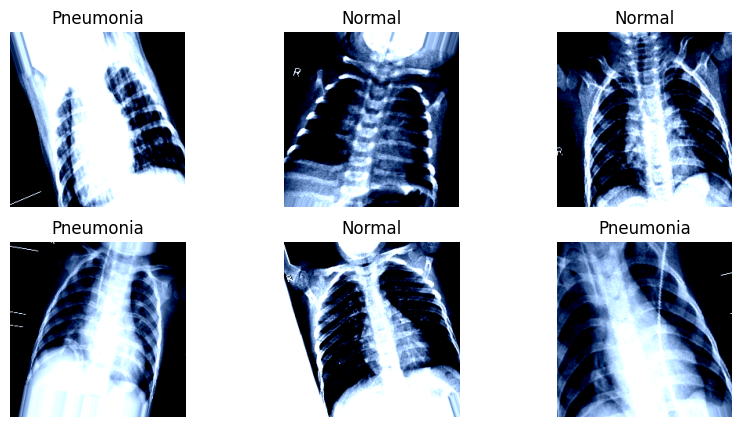

In [6]:
images, labels= next(train_image)

plt.figure(figsize=(10, 5))

for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i])
    plt.title("Pneumonia" if labels[i] ==1 else "Normal")
    plt.axis("off")
    
plt.show()

In [7]:
base_model=DenseNet121(
    weights='imagenet',
    include_top= False,
    input_shape=(224,224,3)
)

In [8]:
for layers in base_model.layers:
    layers.trainable=False

In [9]:
from tensorflow.keras.layers import (
    Dense,
    Dropout
    )

In [10]:
x= base_model.output
x= GlobalAveragePooling2D()(x)
x= Dense(128, activation='relu')(x)
x= Dropout(0.5)(x)

predictions=Dense(1, activation ='sigmoid')(x)

In [11]:
model=Model(
    inputs=base_model.input, 
    outputs=predictions
)

In [12]:
model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping

In [14]:
early_stop= EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
    )

In [15]:
history=model.fit(
    train_image, 
    validation_data= val_image,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 629ms/step - accuracy: 0.8620 - loss: 0.3282 - val_accuracy: 0.8750 - val_loss: 0.2567
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 104s 634ms/step - accuracy: 0.9339 - loss: 0.1755 - val_accuracy: 0.8750 - val_loss: 0.2190
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 621ms/step - accuracy: 0.9354 - loss: 0.1696 - val_accuracy: 0.8125 - val_loss: 0.2253
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 621ms/step - accuracy: 0.9396 - loss: 0.1557 - val_accuracy: 0.9375 - val_loss: 0.1808
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 102s 625ms/step - accuracy: 0.9465 - loss: 0.1342 - val_accuracy: 0.9375 - val_loss: 0.1631
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 115s 705ms/step - accuracy: 0.9421 - loss: 0.1443 - val_accuracy: 0.9375 - val_loss: 0.1346
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 621ms/step - accuracy: 0.9511 - loss: 0.1269 - val_accuracy: 0.9375 - val_loss: 0.1333
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 102s 626ms/step - accuracy: 0.9548 -

In [16]:
test_loss, test_accuracy= model.evaluate(test_image)
print("Test Loss", test_loss)
print('Test Accuracy', test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 628ms/step - accuracy: 0.8622 - loss: 0.3635
Test Loss 0.36352863907814026
Test Accuracy 0.8621794581413269


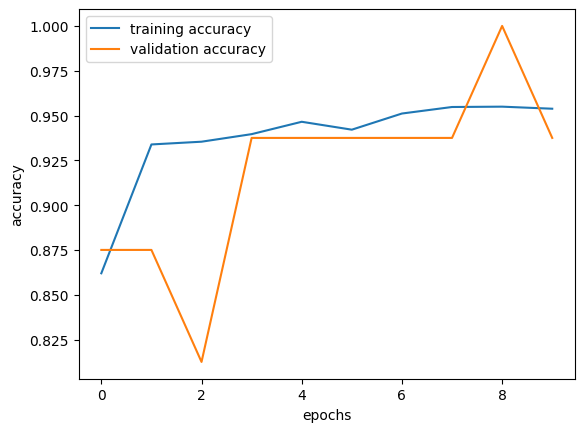

In [17]:
plt.plot(history.history['accuracy'], label='training accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')

plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()

plt.show()

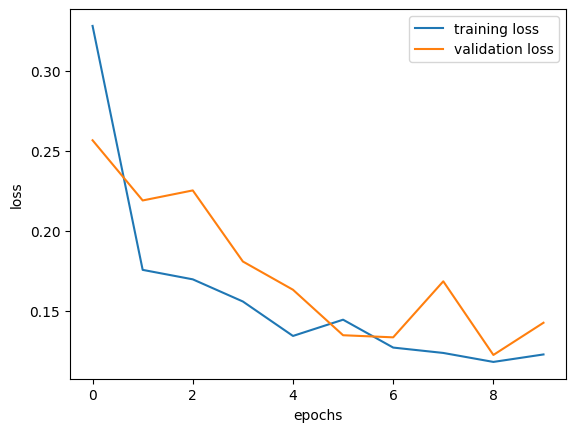

In [18]:
plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label= 'validation loss')

plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()

plt.show()

In [19]:
test_image.reset()

In [20]:
predictons_image=model.predict(test_image)

20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 673ms/step


In [21]:
predicted_classes=(predictons_image > 0.5).astype('int32')

In [22]:
true_classes=test_image.classes

In [23]:
from sklearn.metrics import classification_report, confusion_matrix

In [24]:
print(classification_report(true_classes, predicted_classes))

              precision    recall  f1-score   support

           0       0.94      0.68      0.79       234
           1       0.83      0.97      0.90       390

    accuracy                           0.86       624
   macro avg       0.89      0.83      0.84       624
weighted avg       0.87      0.86      0.86       624



In [25]:
model.save("../model/densenet_freeze.h5")